# 과제 1 - SVM 회귀


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [123]:
# 데이터 로드
california_housing = fetch_california_housing(as_frame=True)
X, y = california_housing.data, california_housing.target

# 위, 경도 데이터 열 삭제
X = X.drop('Latitude', axis = 1)
X = X.drop('Longitude', axis = 1)

# 데이터 스케일
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [124]:
# 모델 생성
svr = SVR(epsilon = 0.01)

# 모델 훈련
svr.fit(X_train, y_train)


SVR(epsilon=0.01)

In [125]:
# 예측
y_pred_scaled = svr.predict(X_test)

# 스케일 복원
y_test = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 0.458358916381014
R-squared: 0.6502168986995819


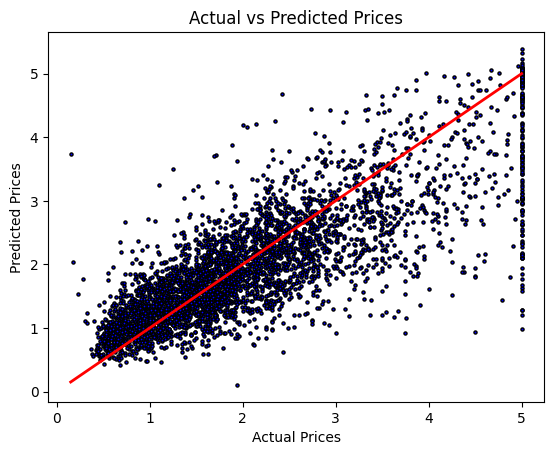

In [126]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [127]:
# 데이터 로드
california_housing = fetch_california_housing(as_frame=True)
X, y = california_housing.data, california_housing.target

# 위, 경도 데이터 열 삭제
X = X.drop('Latitude', axis = 1)
X = X.drop('Longitude', axis = 1)

# 데이터 스케일
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [128]:
# 모델 생성
your_svre3 = SVR(epsilon = 0.001)
your_svre1 = SVR(epsilon = 0.01)
your_svr1 = SVR(epsilon = 1)
your_svr15 = SVR(epsilon = 1.5)
your_svr2 = SVR(epsilon = 2)

# 모델 훈련
your_svre3.fit(X_train, y_train)
your_svre1.fit(X_train, y_train)
your_svr1.fit(X_train, y_train)
your_svr15.fit(X_train, y_train)
your_svr2.fit(X_train, y_train)


SVR(epsilon=2)

In [129]:
# 예측
y_pred_scalede3 = your_svre3.predict(X_test)
y_pred_scalede1 = your_svre1.predict(X_test)
y_pred_scaled1 = your_svr1.predict(X_test)
y_pred_scaled15 = your_svr15.predict(X_test)
y_pred_scaled2 = your_svr2.predict(X_test)

In [130]:
# 스케일 복원
y_test = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_prede3 = scaler_y.inverse_transform(y_pred_scalede3.reshape(-1,1))
y_prede1 = scaler_y.inverse_transform(y_pred_scalede1.reshape(-1,1))
y_pred1 = scaler_y.inverse_transform(y_pred_scaled1.reshape(-1,1))
y_pred15 = scaler_y.inverse_transform(y_pred_scaled15.reshape(-1,1))
y_pred2 = scaler_y.inverse_transform(y_pred_scaled2.reshape(-1,1))

In [131]:
# 성능 평가
mse_2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)
print("Mean Squared Error(epsilon=2):", mse_2)
print("R-squared:", r2_2)

mse_15 = mean_squared_error(y_test, y_pred15)
r2_15 = r2_score(y_test, y_pred15)
print("Mean Squared Error(epsilon=1.5):", mse_15)
print("R-squared:", r2_15)

mse_1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)
print("Mean Squared Error(epsilon=1):", mse_1)
print("R-squared:", r2_1)

mse_e1 = mean_squared_error(y_test, y_prede1)
r2_e1 = r2_score(y_test, y_prede1)
print("Mean Squared Error(epsilon=0.1):", mse_e1)
print("R-squared:", r2_e1)

mse_e3 = mean_squared_error(y_test, y_prede3)
r2_e3 = r2_score(y_test, y_prede3)
print("Mean Squared Error(epsilon=0.001):", mse_e3)
print("R-squared:", r2_e3)

Mean Squared Error(epsilon=2): 1.7024206499803964
R-squared: -0.29915215650135063
Mean Squared Error(epsilon=1.5): 1.0408736616357062
R-squared: 0.20568793489725556
Mean Squared Error(epsilon=1): 0.5737535748111724
R-squared: 0.5621568652701217
Mean Squared Error(epsilon=0.1): 0.458358916381014
R-squared: 0.6502168986995819
Mean Squared Error(epsilon=0.001): 0.45821911089118994
R-squared: 0.6503235871397143


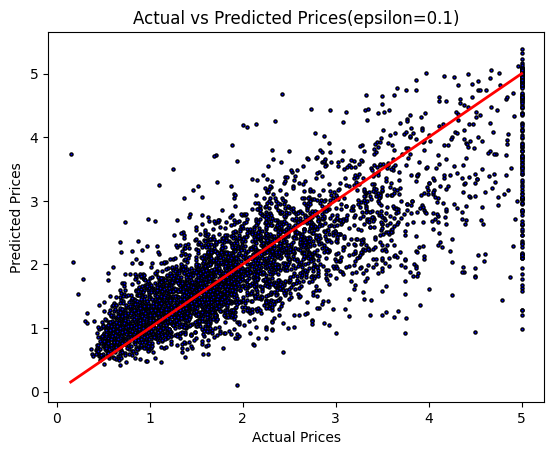

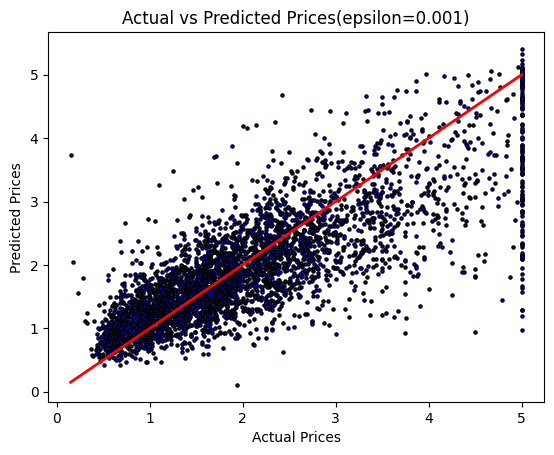

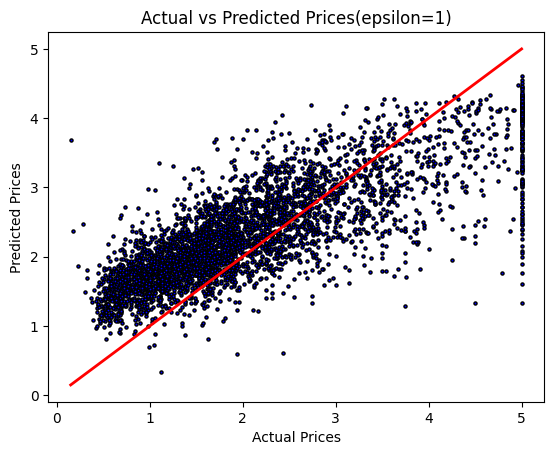

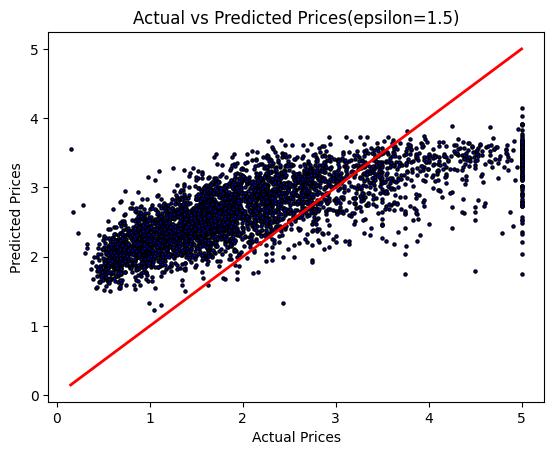

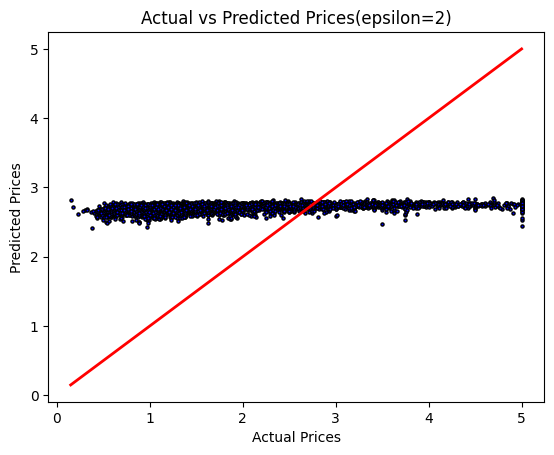

In [132]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_prede1, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices(epsilon=0.1)')
plt.show()

plt.scatter(y_test, y_prede3, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices(epsilon=0.001)')
plt.show()

plt.scatter(y_test, y_pred1, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices(epsilon=1)')
plt.show()

plt.scatter(y_test, y_pred15, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices(epsilon=1.5)')
plt.show()

plt.scatter(y_test, y_pred2, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices(epsilon=2)')
plt.show()

svr에서 epsilon 파라미터는 Epsilon-insensitive loss를 정의합니다.
예측값과 실제값 사이의 절대 오차가 epsilon 이하인 경우에는 손실을 0으로 간주합니다.
오차가 epsilon보다 클 때에만 해당 차이에 비례한 손실이 발생합니다.
mse와 r2 score를 보면 epsilon이 0.1, 0.001일 때는 예측을 0.01일때와 비슷하게 했다고 볼 수 있다. 그러나 확실한 건 단순 mse와 r2 score만으로는 평가가 완전하지는 않다는 것이다.
실제 가격이 5인쪽을 보면 이상치에 대해서 잘 예측이 이루어지지 않았다는 것을 알 수 있다. 그리고 epsilon=1.5일 때부터 예측값의 분포가 가로로 누우면서 이상해지기 시작하는데 이건 오차가 0으로 잡히는 데이터의 수가 많아서 그런 것으로 보이고 epsilon=2일때를 보면 예측가격이 대충 데이터들의 평균인 3 근처에서 형성된 것으로 보아 평균 근처로 그냥 hyperplane을 그어도 전부 오차가 0으로 잡혀서 이런 결과가 나온 것으로 보인다.


# 과제 1-2 : SVM 분류

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [141]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

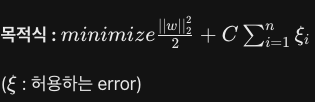


In [142]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.1, 0.01, 0.001, 1, 1.5, 2, 5, 10, 100] # Todo
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.1:
Training Accuracy: 0.9666666666666667
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--------------------------------------------------
C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

------

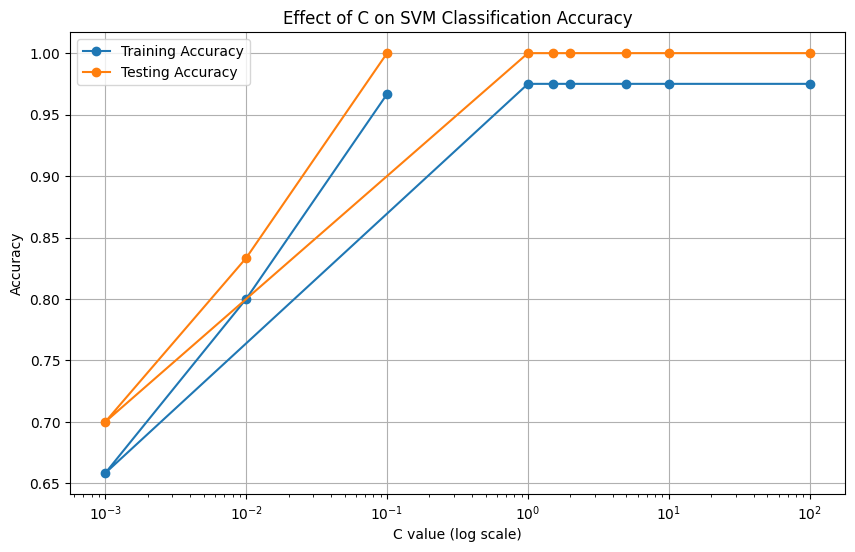

In [143]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()
